# Diabetes Readmission — Feature Selection

Dummy-encoding turned a few dozen clinical fields into a wide matrix, and most of those columns
contribute nothing. This notebook prunes them twice over: first by **importance**, keeping the
features a gradient-boosted model actually splits on, then by **VIF**, iteratively removing what is
redundant given the rest.

Then it refits the same model lineup on the survivors, and asks the question that matters: did
performance suffer?

## Learning objectives

- Rank features by a tree model's importance and keep the useful ones
- Iteratively remove collinear features by VIF until all survivors fall below a threshold
- Explain why importance-pruning and VIF-pruning remove different columns
- Re-fit a model lineup on a reduced feature set and compare per-class F1 before and after

## Background

This notebook assumes the preprocessed table from `U1_Diabetes-2_Preprocess`, the model lineup and
per-class F1 reasoning from `U1_Diabetes-3_Classification`, and the two pruning tools from Unit 1
section 4 — importance from `U1-4_FeatSelect-2_FeatureImportance` and the variance inflation factor
from `U1-4_FeatSelect-1_VIF`. Both are applied here rather than re-derived.

**Prerequisites:** `U1_Diabetes-3_Classification` (models and metrics),
`U1-4_FeatSelect-1_VIF`, `U1-4_FeatSelect-2_FeatureImportance`

**Dataset:** `diabetes_hospital_preprocessed.csv` — subsampled to 25,000 encounters.

**References:** https://scikit-learn.org/stable/modules/feature_selection.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from tqdm import tqdm

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Load the preprocessed data

`U1_Diabetes-2_Preprocess` already dropped the leakage columns and dummy-encoded every
categorical, saving the result to `diabetes_hospital_preprocessed.csv`. We load that and go
straight to modeling.

### 1.1 Subsample

The full dataset is ~102k encounters — fine for production, slow for classroom experimentation. We
take a **seeded, stratified** subsample of 25,000: stratified so the ~11% positive rate is
preserved exactly, seeded so every notebook in this spine sees the same 25,000 patients and their
results are comparable.

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

# Load the fully preprocessed dataset saved by notebook 2.
df = pd.read_csv(data_folder + 'Diabetes/diabetes_hospital_preprocessed.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype
---  ------                                      --------------   -----
 0   age                                         101766 non-null  int64
 1   time_in_hospital                            101766 non-null  int64
 2   num_lab_procedures                          101766 non-null  int64
 3   num_procedures                              101766 non-null  int64
 4   num_medications                             101766 non-null  int64
 5   number_diagnoses                            101766 non-null  int64
 6   readmit_30_days                             101766 non-null  int64
 7   race_AfricanAmerican                        101766 non-null  int64
 8   race_Asian                                  101766 non-null  int64
 9   race_Hispanic                               101766 non-null  int64
 10  race_Other          

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,readmit_30_days,race_AfricanAmerican,race_Asian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown/Invalid,discharge_disposition_id_Other,admission_source_id_Other,admission_source_id_Referral,medical_specialty_Cardiology,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Other,primary_diagnosis_'Genitourinary Issues',primary_diagnosis_'Musculoskeletal Issues',primary_diagnosis_'Respiratory Issues',primary_diagnosis_Diabetes,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_Norm,insulin_Down,insulin_Steady,insulin_Up,change_Ch,diabetesMed_No,medicare_True,medicaid_True,had_emergency_True,had_inpatient_days_True,had_outpatient_days_True
0,0,1,41,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,3,59,0,18,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
2,0,2,11,5,13,6,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,1,2,44,1,16,7,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
4,1,1,51,0,8,5,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0


The full dataset has ~102k encounters — great for production, slow for classroom experimentation. We work with a seeded **stratified** subsample of 25,000 rows (~2,800 positives), which preserves the class ratio.

In [3]:
from sklearn.model_selection import train_test_split

df, _ = train_test_split(
    df,
    train_size=25_000,
    stratify=df['readmit_30_days'],
    random_state=42
)
df = df.reset_index(drop=True)

print(df.shape)
print(f"positive rate: {df['readmit_30_days'].mean():.1%}")

(25000, 42)
positive rate: 11.2%


## 2. Prepare the data for modeling

In [4]:
df.sample(5)

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,readmit_30_days,race_AfricanAmerican,race_Asian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown/Invalid,discharge_disposition_id_Other,admission_source_id_Other,admission_source_id_Referral,medical_specialty_Cardiology,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Other,primary_diagnosis_'Genitourinary Issues',primary_diagnosis_'Musculoskeletal Issues',primary_diagnosis_'Respiratory Issues',primary_diagnosis_Diabetes,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_Norm,insulin_Down,insulin_Steady,insulin_Up,change_Ch,diabetesMed_No,medicare_True,medicaid_True,had_emergency_True,had_inpatient_days_True,had_outpatient_days_True
22660,2,5,43,6,21,7,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
24176,2,1,65,0,7,5,0,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
6302,1,3,61,0,15,9,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,1,1
17411,2,4,42,0,18,9,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
18292,1,6,47,3,12,4,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0


In [5]:
label = 'readmit_30_days'

# Binary target: already 0/1, so no rare-class filtering or label encoding is needed.
X_raw = df.drop(columns=[label])
y = df[label].copy()

y.value_counts()

readmit_30_days
0    22210
1     2790
Name: count, dtype: int64

### 2.1 Scale the features

Everything loaded from notebook 2 is numeric — ordinal age plus dummy columns — so the whole
matrix is scaled. Tree models are indifferent to feature scale, but logistic regression, KNN, and
neural networks are not, and we are about to compare all of them on equal footing.

In [6]:
from sklearn.preprocessing import StandardScaler

# The data loaded from notebook 2 is already dummy-encoded, so every feature
# column is numeric. We scale the entire feature matrix to zero mean, unit variance.
std_scaler = StandardScaler()

X = pd.DataFrame(
    std_scaler.fit_transform(X_raw),
    columns=X_raw.columns,
    index=X_raw.index
)

X.head()

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,race_AfricanAmerican,race_Asian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown/Invalid,discharge_disposition_id_Other,admission_source_id_Other,admission_source_id_Referral,medical_specialty_Cardiology,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Other,primary_diagnosis_'Genitourinary Issues',primary_diagnosis_'Musculoskeletal Issues',primary_diagnosis_'Respiratory Issues',primary_diagnosis_Diabetes,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_Norm,insulin_Down,insulin_Steady,insulin_Up,change_Ch,diabetesMed_No,medicare_True,medicaid_True,had_emergency_True,had_inpatient_days_True,had_outpatient_days_True
0,0.667206,2.562889,2.339641,-0.195398,1.714086,0.818711,-0.483441,-0.078471,-0.148301,-0.123404,-0.149704,1.080077,-0.008945,1.206164,-0.390375,-0.662582,-0.240226,3.499792,-0.281285,-0.407619,-0.446075,-0.229222,-0.228836,-0.406083,3.261707,-0.122229,-0.112782,-0.162088,-0.199292,3.406928,-0.229512,2.673196,-0.658397,-0.354428,1.070564,-0.546165,1.469204,-0.193136,2.821449,-0.702064,-0.443688
1,0.667206,-1.137830,0.409234,-0.783592,-0.982776,-0.734427,-0.483441,-0.078471,-0.148301,8.103497,-0.149704,1.080077,-0.008945,-0.829075,-0.390375,-0.662582,-0.240226,-0.285731,-0.281285,2.453269,-0.446075,-0.229222,-0.228836,2.462548,-0.306588,-0.122229,-0.112782,6.169481,-0.199292,-0.293520,-0.229512,-0.374084,-0.658397,-0.354428,-0.934087,1.830947,-0.680641,-0.193136,-0.354428,-0.702064,-0.443688
2,0.667206,-0.801401,0.714035,-0.783592,-0.492437,-1.252140,2.068506,-0.078471,-0.148301,-0.123404,-0.149704,-0.925860,-0.008945,-0.829075,-0.390375,-0.662582,-0.240226,-0.285731,-0.281285,-0.407619,-0.446075,-0.229222,-0.228836,-0.406083,-0.306588,-0.122229,-0.112782,-0.162088,-0.199292,-0.293520,-0.229512,2.673196,-0.658397,-0.354428,1.070564,-0.546165,-0.680641,-0.193136,-0.354428,1.424372,2.253834
3,0.667206,1.553602,0.510834,-0.195398,-0.124683,-1.252140,-0.483441,-0.078471,-0.148301,-0.123404,-0.149704,-0.925860,-0.008945,1.206164,-0.390375,-0.662582,-0.240226,-0.285731,-0.281285,2.453269,-0.446075,-0.229222,-0.228836,-0.406083,-0.306588,-0.122229,8.866670,-0.162088,-0.199292,-0.293520,-0.229512,-0.374084,-0.658397,-0.354428,-0.934087,1.830947,-0.680641,-0.193136,-0.354428,1.424372,-0.443688
4,0.667206,-0.801401,-0.911571,-0.783592,-0.615022,-0.734427,-0.483441,-0.078471,-0.148301,-0.123404,-0.149704,-0.925860,-0.008945,-0.829075,-0.390375,1.509248,-0.240226,-0.285731,-0.281285,-0.407619,2.241773,-0.229222,-0.228836,2.462548,-0.306588,-0.122229,-0.112782,-0.162088,-0.199292,-0.293520,-0.229512,-0.374084,1.518841,-0.354428,-0.934087,-0.546165,-0.680641,-0.193136,2.821449,-0.702064,-0.443688


## 3. Modeling on all features

Logistic regression and the random forests use `class_weight='balanced'` (~11% positives — see `U1_Diabetes-3_Classification`); KNN and gradient boosting have no such option.

This is the **baseline** every pruned version is measured against. Record the per-class F1 here;
the whole notebook is an argument about whether a smaller feature set can match it.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = [
    LogisticRegression(class_weight='balanced'),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform', n_jobs=-1),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform', n_jobs=-1),
    KNeighborsClassifier(n_neighbors=50,  weights='uniform', n_jobs=-1),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3, class_weight='balanced'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10, class_weight='balanced'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30, class_weight='balanced'),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
]

LogisticRegression(class_weight='balanced')


              precision    recall  f1-score   support

           0       0.92      0.62      0.74      4442
           1       0.16      0.57      0.25       558

    accuracy                           0.61      5000
   macro avg       0.54      0.60      0.49      5000
weighted avg       0.84      0.61      0.68      5000



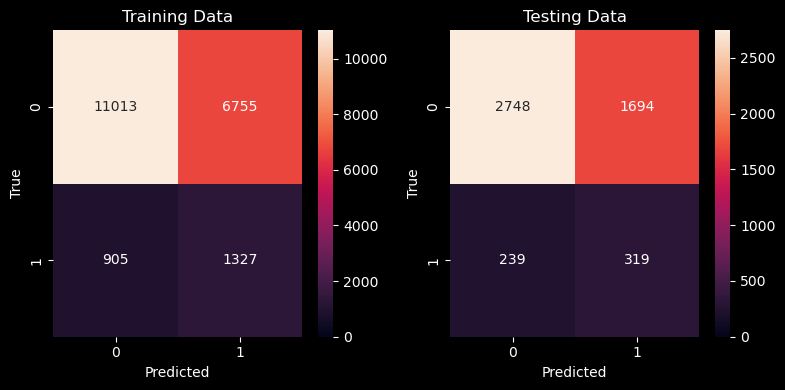

KNeighborsClassifier(n_jobs=-1)
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      4442
           1       0.25      0.03      0.06       558

    accuracy                           0.88      5000
   macro avg       0.57      0.51      0.50      5000
weighted avg       0.82      0.88      0.84      5000



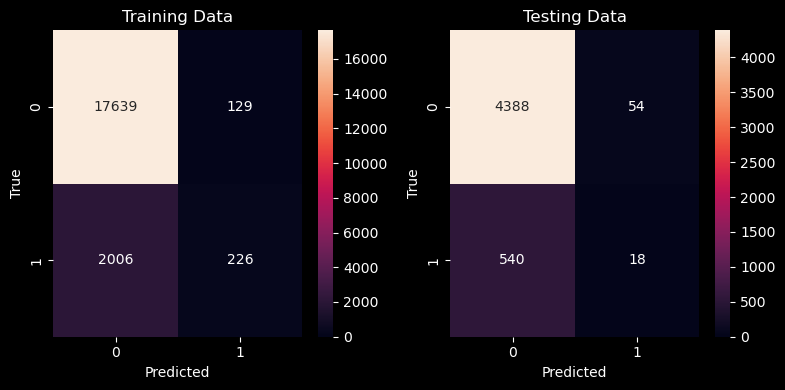

KNeighborsClassifier(n_jobs=-1, n_neighbors=10)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.33      0.00      0.01       558

    accuracy                           0.89      5000
   macro avg       0.61      0.50      0.47      5000
weighted avg       0.83      0.89      0.84      5000



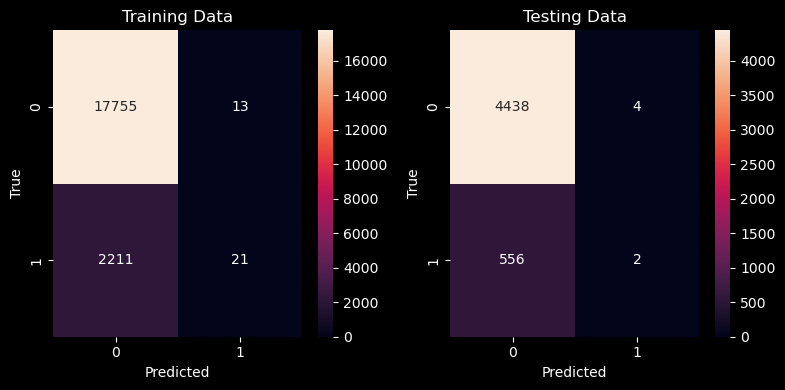

KNeighborsClassifier(n_jobs=-1, n_neighbors=50)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.00      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.79      0.89      0.84      5000



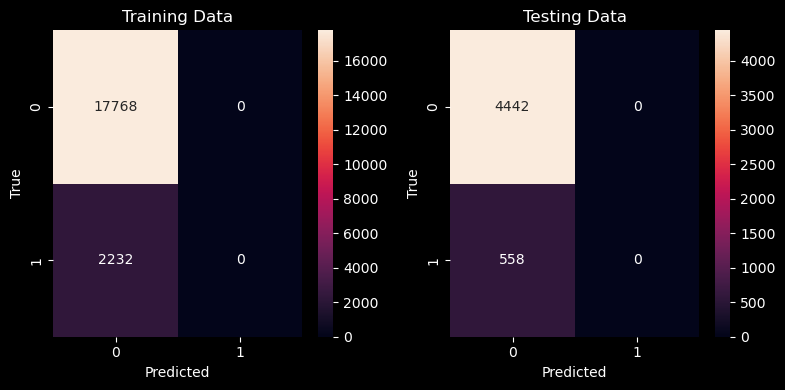

RandomForestClassifier(class_weight='balanced', max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.92      0.63      0.75      4442
           1       0.16      0.54      0.24       558

    accuracy                           0.62      5000
   macro avg       0.54      0.59      0.50      5000
weighted avg       0.83      0.62      0.69      5000



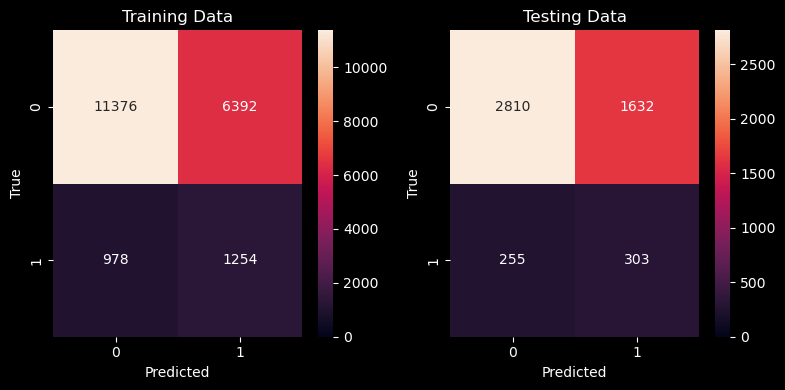

RandomForestClassifier(class_weight='balanced', max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.92      0.55      0.69      4442
           1       0.15      0.63      0.24       558

    accuracy                           0.56      5000
   macro avg       0.54      0.59      0.47      5000
weighted avg       0.84      0.56      0.64      5000



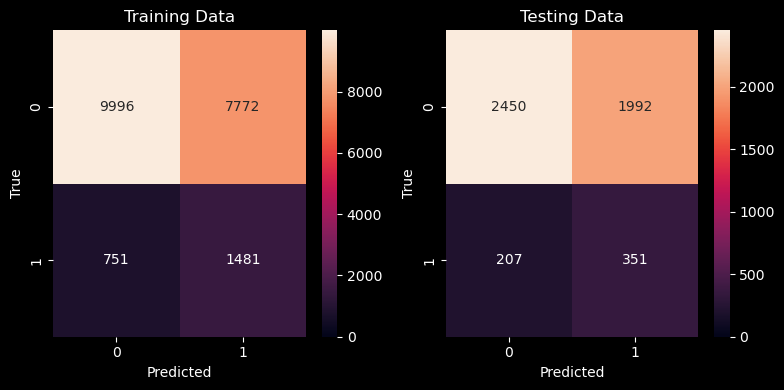

RandomForestClassifier(class_weight='balanced', max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.92      0.58      0.71      4442
           1       0.15      0.60      0.24       558

    accuracy                           0.59      5000
   macro avg       0.54      0.59      0.48      5000
weighted avg       0.84      0.59      0.66      5000



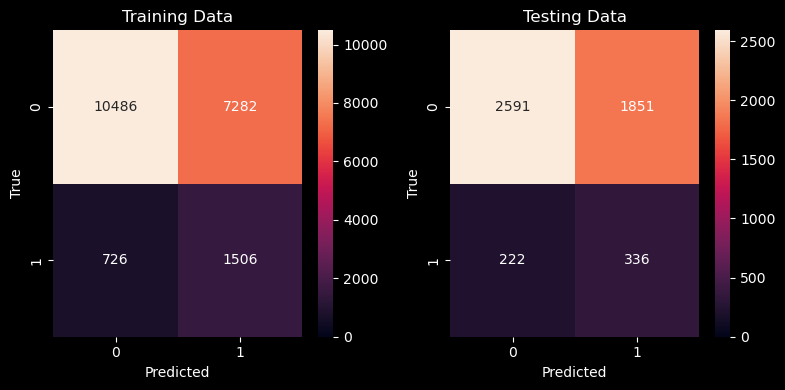

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.00      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.79      0.89      0.84      5000



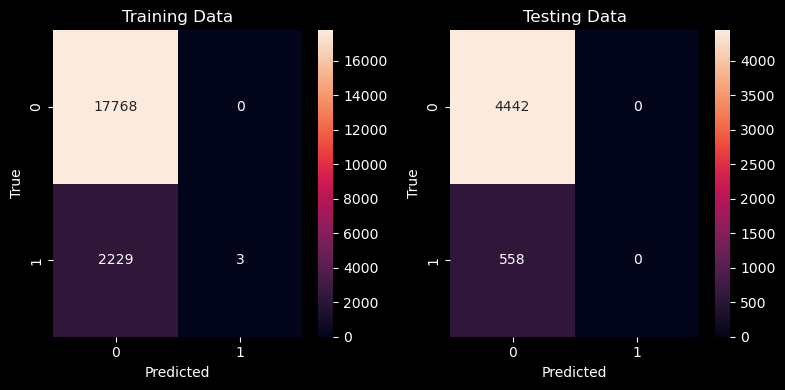

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.00      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.79      0.89      0.84      5000



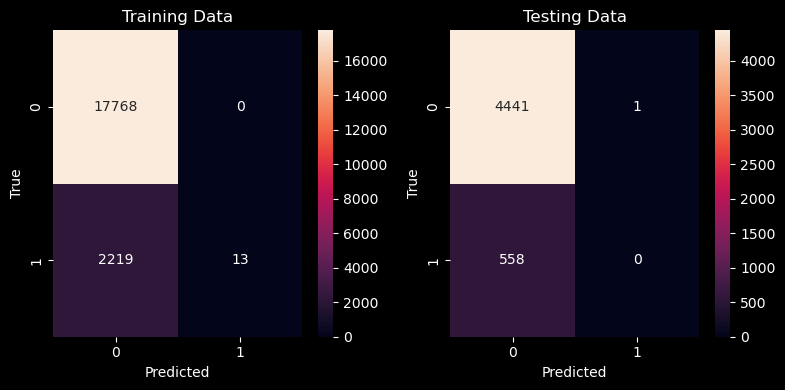

,0,1,avg_f1
model,,,
KNeighborsClassifier(n_jobs=-1),0.936606,0.057143,0.496875
"RandomForestClassifier(class_weight='balanced', max_leaf_nodes=3)",0.748635,0.243081,0.495858
LogisticRegression(class_weight='balanced'),0.739803,0.248152,0.493978
"RandomForestClassifier(class_weight='balanced', max_leaf_nodes=30)",0.714266,0.244809,0.479537
"KNeighborsClassifier(n_jobs=-1, n_neighbors=10)",0.940653,0.007092,0.473873
"KNeighborsClassifier(n_jobs=-1, n_neighbors=50)",0.940902,0.000000,0.470451
GradientBoostingClassifier(max_leaf_nodes=3),0.940902,0.000000,0.470451
GradientBoostingClassifier(max_leaf_nodes=10),0.940790,0.000000,0.470395
"RandomForestClassifier(class_weight='balanced', max_leaf_nodes=10)",0.690238,0.241986,0.466112


In [9]:
from sklearn.metrics import classification_report, confusion_matrix

# Store per-class F1 scores here
f1_rows = []

for m in models:
    m.fit(X_train, y_train)
    y_train_pred = m.predict(X_train)
    y_test_pred = m.predict(X_test)
    
    print(m)
    print(classification_report(y_test, y_test_pred))

    # --- Extract per-class F1 scores ---
    model_name = str(m)

    # --- Classification report ---
    report_dict = classification_report(
        y_test,
        y_test_pred,
        output_dict=True
    )

    f1_scores = {
        cls: metrics["f1-score"]
        for cls, metrics in report_dict.items()
        if cls not in ["accuracy", "macro avg", "weighted avg"]
    }

    f1_scores["model"] = model_name

    f1_rows.append(f1_scores)

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)
    
    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
    
    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")
    
    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")
    
    # Show the plots
    plt.tight_layout()
    plt.show()
# end

# --- Build final DataFrame ---
f1_df = pd.DataFrame(f1_rows)
f1_df = f1_df.set_index("model")
f1_df = f1_df.reindex(sorted(f1_df.columns, key=float), axis=1)
f1_df['avg_f1'] = f1_df.mean(axis=1)

f1_df.sort_values(by='avg_f1', ascending=False)

## 4. Parsimony — pruning the feature set

### 4.1 Prune by importance

A gradient-boosted model is fit on everything, and its `feature_importances_` rank the columns by
how much impurity reduction each one delivered. Keeping the top slice discards the columns the
model never found a use for.

One caveat carried over from `U1-4_FeatSelect-2_FeatureImportance`: importance is computed on
training data and is biased toward high-cardinality features. With mostly 0/1 dummy columns here,
that bias favours the few continuous utilization counts — which is worth knowing before reading the
ranking as ground truth.

In [10]:
# Fit a Random Forest model
gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_leaf_nodes=10
)
gb.fit(X_train, y_train)

# Get feature importances
importances = pd.Series(
    gb.feature_importances_, index=X.columns
).sort_values(ascending=False)

importances = importances[:100]

features_gb = importances.index

X_pars = X[ features_gb ]
importances

had_inpatient_days_True                       0.300456
num_lab_procedures                            0.116924
num_medications                               0.094488
discharge_disposition_id_Other                0.090049
time_in_hospital                              0.059938
had_emergency_True                            0.040269
age                                           0.035723
number_diagnoses                              0.029579
num_procedures                                0.027507
diabetesMed_No                                0.017180
max_glu_serum_Norm                            0.013762
medicare_True                                 0.013747
primary_diagnosis_Diabetes                    0.012566
insulin_Up                                    0.011566
race_Asian                                    0.010686
gender_Male                                   0.009870
medicaid_True                                 0.009847
insulin_Down                                  0.008233
primary_di

### 4.2 Prune by variance inflation factor

Importance and VIF remove different things, which is why both are worth running. Importance asks
"is this feature **useful**?"; VIF asks "is this feature **redundant** given the others?" A column
can be genuinely predictive and still redundant — two dummy columns encoding nearly the same
clinical fact will both look important while carrying one fact between them.

The loop removes the highest-VIF feature, recomputes every VIF on what remains, and repeats. The
recomputation is essential: VIF is a property of the whole set, so dropping one column changes the
value for all the others, and often removing one member of a collinear group drops the rest back
into the acceptable range on its own.

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_pars_with_const = sm.add_constant(X_pars)

vif = pd.Series(
    [variance_inflation_factor(X_pars_with_const.values, i) for i in range(X_pars_with_const.shape[1])],
    index=X_pars_with_const.columns
).sort_values(ascending=False)

vif[:10]

change_Ch                       1.956010
num_medications                 1.802131
insulin_Down                    1.769851
diabetesMed_No                  1.742720
insulin_Up                      1.724630
insulin_Steady                  1.676685
time_in_hospital                1.483414
admission_source_id_Referral    1.410301
admission_source_id_Other       1.406529
num_lab_procedures              1.387964
dtype: float64

In [12]:
# Copy dataset to avoid modifying the original
X_vif = X_pars.copy()

# Iteratively remove features with high VIF
while True:
    # Add constant for intercept
    X_vif_with_const = sm.add_constant(X_vif)
    
    # Compute VIF for all features
    vif_series = pd.Series(
        [variance_inflation_factor(X_vif_with_const.values, i) for i in range(X_vif_with_const.shape[1])],
        index=X_vif_with_const.columns
    )
    
    # Exclude constant term and get the feature with the highest VIF
    vif_series = vif_series.drop('const', errors='ignore')
    highest_vif_feature = vif_series.idxmax()
    #display(vif_series)
    
    # Break the loop if all features have VIF ≤ 10
    if vif_series.loc[highest_vif_feature] <= 10:  # Checking the first feature after 'const'
        break

    # Drop the feature with the highest VIF
    X_vif = X_vif.drop(columns=[highest_vif_feature])

    print(f"Dropped: {highest_vif_feature} (VIF={vif_series.loc[highest_vif_feature]:.2f})")
# end

vif_series.sort_values(ascending=False)[:10]

change_Ch                       1.956010
num_medications                 1.802131
insulin_Down                    1.769851
diabetesMed_No                  1.742720
insulin_Up                      1.724630
insulin_Steady                  1.676685
time_in_hospital                1.483414
admission_source_id_Referral    1.410301
admission_source_id_Other       1.406529
num_lab_procedures              1.387964
dtype: float64

## 5. Re-fit on the surviving features

Same model zoo, but now restricted to the columns that survived the importance + VIF pruning.

Compare per-class F1 against the section 3 baseline. The result to hope for is **not** an
improvement — it is *no meaningful loss* on a much smaller feature set. A model with a fraction of
the columns that performs the same is cheaper to fit, easier to explain to a clinician, and less
liable to break when one field goes missing.

If minority-class F1 does drop noticeably, the pruning went too far, and the importance cutoff is
the knob to relax.

LogisticRegression(class_weight='balanced')
              precision    recall  f1-score   support

           0       0.92      0.62      0.74      4442
           1       0.16      0.57      0.25       558

    accuracy                           0.61      5000
   macro avg       0.54      0.60      0.49      5000
weighted avg       0.84      0.61      0.68      5000



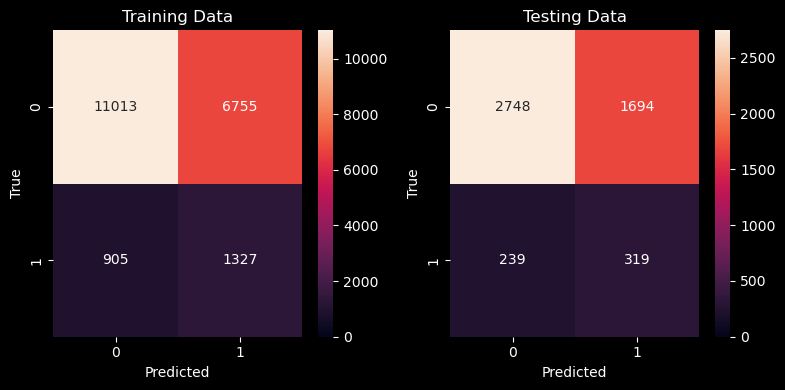

KNeighborsClassifier(n_jobs=-1)
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      4442
           1       0.25      0.03      0.06       558

    accuracy                           0.88      5000
   macro avg       0.57      0.51      0.50      5000
weighted avg       0.82      0.88      0.84      5000



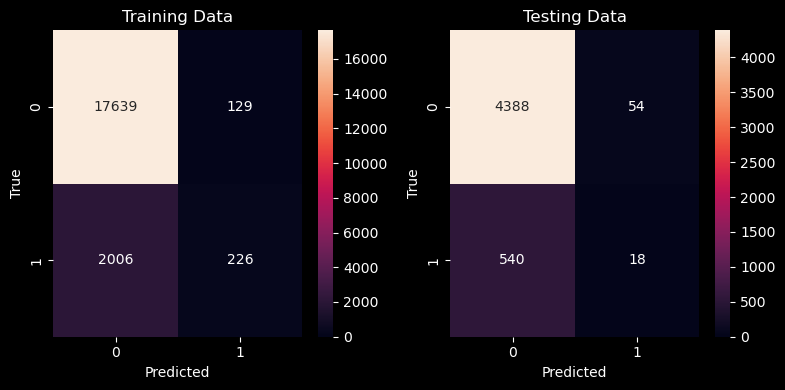

KNeighborsClassifier(n_jobs=-1, n_neighbors=10)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.33      0.00      0.01       558

    accuracy                           0.89      5000
   macro avg       0.61      0.50      0.47      5000
weighted avg       0.83      0.89      0.84      5000



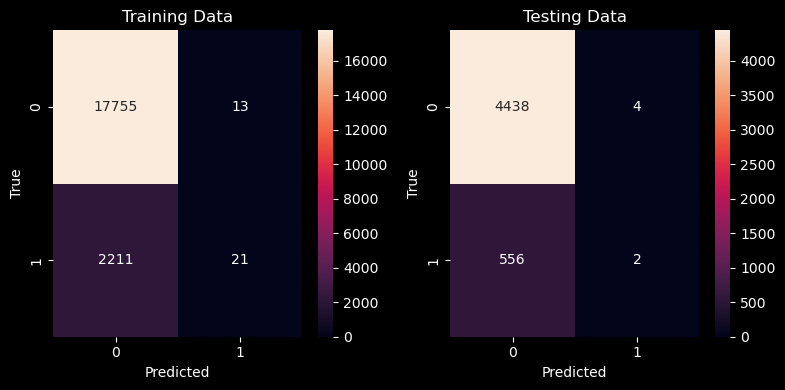

KNeighborsClassifier(n_jobs=-1, n_neighbors=50)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.00      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.79      0.89      0.84      5000



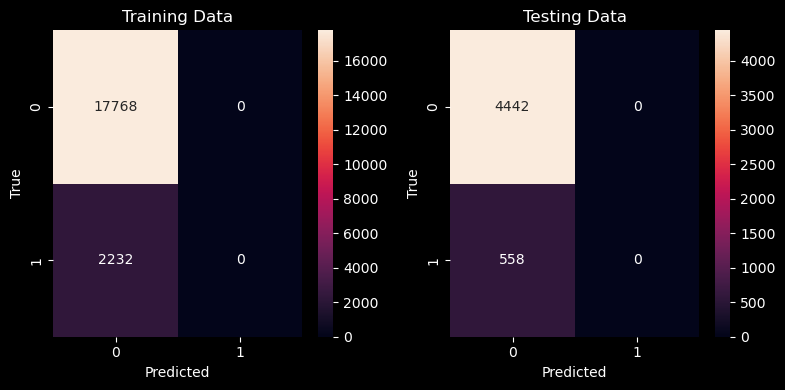

RandomForestClassifier(class_weight='balanced', max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.92      0.58      0.71      4442
           1       0.15      0.59      0.24       558

    accuracy                           0.58      5000
   macro avg       0.53      0.58      0.48      5000
weighted avg       0.83      0.58      0.66      5000



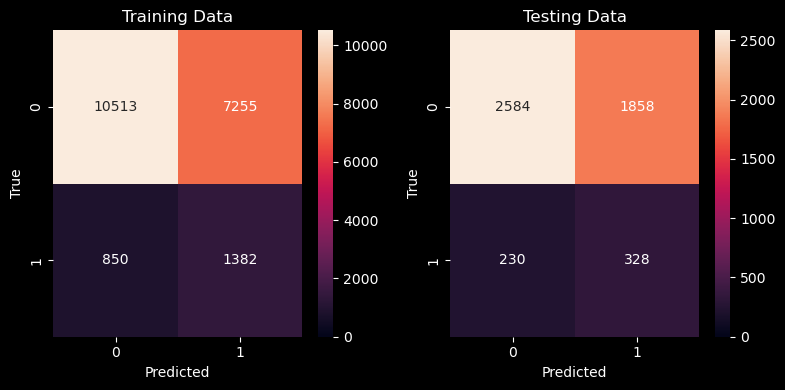

RandomForestClassifier(class_weight='balanced', max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.92      0.57      0.71      4442
           1       0.15      0.61      0.24       558

    accuracy                           0.58      5000
   macro avg       0.54      0.59      0.47      5000
weighted avg       0.83      0.58      0.65      5000



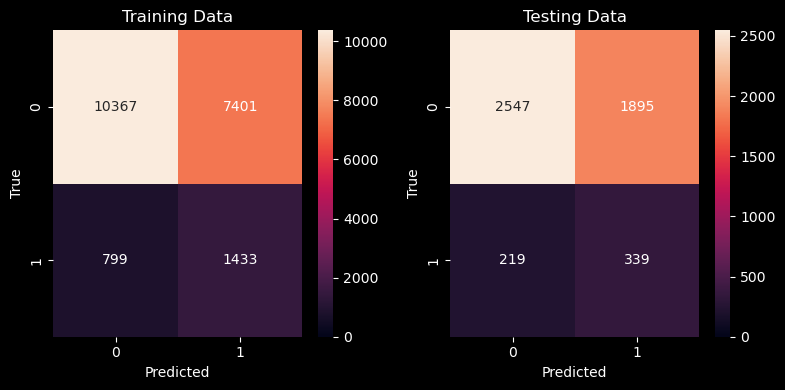

RandomForestClassifier(class_weight='balanced', max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.92      0.59      0.72      4442
           1       0.15      0.60      0.25       558

    accuracy                           0.59      5000
   macro avg       0.54      0.59      0.48      5000
weighted avg       0.84      0.59      0.66      5000



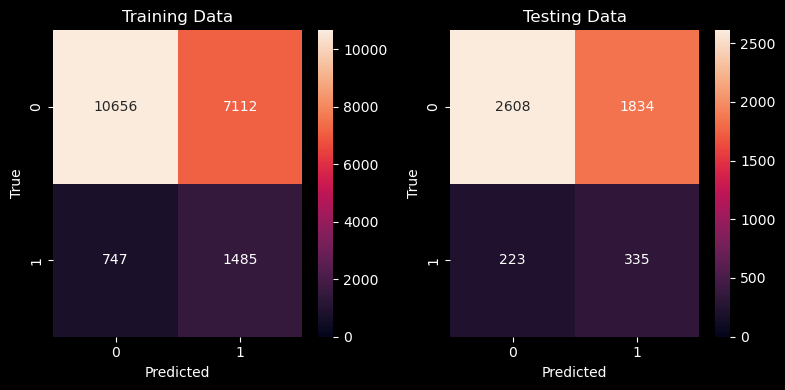

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.00      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.79      0.89      0.84      5000



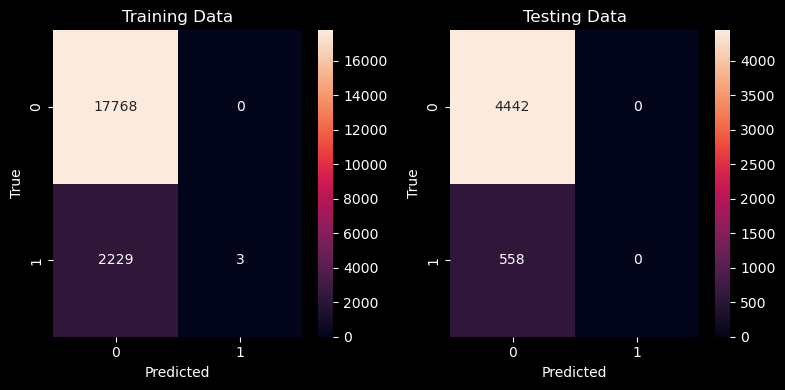

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.00      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.79      0.89      0.84      5000



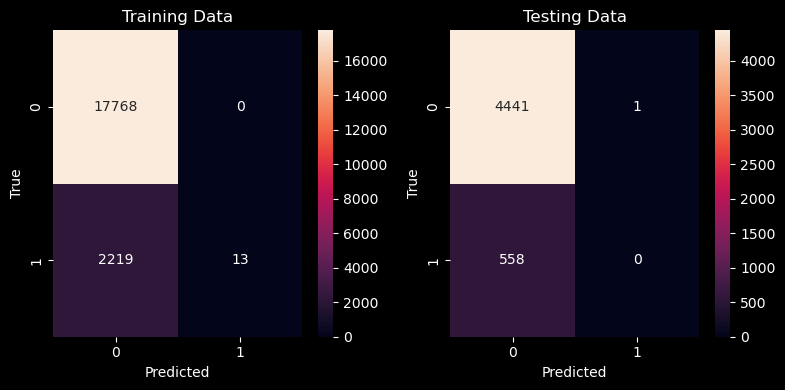

,0,1,avg_f1
model,,,
KNeighborsClassifier(n_jobs=-1),0.936606,0.057143,0.496875
LogisticRegression(class_weight='balanced'),0.739803,0.248152,0.493978
"RandomForestClassifier(class_weight='balanced', max_leaf_nodes=30)",0.717173,0.245691,0.481432
"RandomForestClassifier(class_weight='balanced', max_leaf_nodes=3)",0.712238,0.239067,0.475653
"RandomForestClassifier(class_weight='balanced', max_leaf_nodes=10)",0.706715,0.242837,0.474776
"KNeighborsClassifier(n_jobs=-1, n_neighbors=10)",0.940653,0.007092,0.473873
"KNeighborsClassifier(n_jobs=-1, n_neighbors=50)",0.940902,0.000000,0.470451
GradientBoostingClassifier(max_leaf_nodes=3),0.940902,0.000000,0.470451
GradientBoostingClassifier(max_leaf_nodes=10),0.940790,0.000000,0.470395


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Store per-class F1 scores here
f1_rows = []

for m in models:
    m.fit(X_train[X_vif.columns], y_train)
    y_train_pred = m.predict(X_train[X_vif.columns])
    y_test_pred = m.predict(X_test[X_vif.columns])
    
    print(m)
    print(classification_report(y_test, y_test_pred))

    # --- Extract per-class F1 scores ---
    model_name = str(m)

    # --- Classification report ---
    report_dict = classification_report(
        y_test,
        y_test_pred,
        output_dict=True
    )

    f1_scores = {
        cls: metrics["f1-score"]
        for cls, metrics in report_dict.items()
        if cls not in ["accuracy", "macro avg", "weighted avg"]
    }

    f1_scores["model"] = model_name

    f1_rows.append(f1_scores)

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)
    
    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
    
    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")
    
    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")
    
    # Show the plots
    plt.tight_layout()
    plt.show()
# end

# --- Build final DataFrame ---
f1_df = pd.DataFrame(f1_rows)
f1_df = f1_df.set_index("model")
f1_df = f1_df.reindex(sorted(f1_df.columns, key=float), axis=1)
f1_df['avg_f1'] = f1_df.mean(axis=1)

f1_df.sort_values(by='avg_f1', ascending=False)

## 6. Review

- **Importance and VIF prune for different reasons.** Importance removes what is *not useful*; VIF
  removes what is *redundant given the rest*. A feature can be both useful and redundant.
- **VIF must be recomputed after every removal**, since it is a property of the whole feature set —
  dropping one member of a collinear group often rescues the others.
- **Impurity importance is biased toward high-cardinality features**, which on a mostly-dummy matrix
  favours the continuous counts.
- **The goal is equal performance on fewer features**, not better performance. Parsimony buys
  cheaper fits, easier explanation, and more robustness — not accuracy.
- **Judge on minority-class F1**, as everywhere in this spine; an 11% positive rate makes aggregate
  metrics unreliable.